After running the cell below, you will be prompted to authorize this notebook to access your Google Drive. Once authorized, your Drive content will be accessible under `/content/drive/My Drive/`.

In [ ]:
import os
import torch

# Detect environment (Colab vs local/GitHub)
try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

    # Optional: only use Drive if you *really* need it
    BASE_PATH = "/content/drive/MyDrive/bimodal-emotion-project"
else:
    # When cloned from GitHub
    BASE_PATH = os.path.abspath(".")

os.chdir(BASE_PATH)

print("Current directory:", os.getcwd())
print("Files:", os.listdir())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Mounted at /content/drive
current directory is : /content/drive/My Drive/Bimodal Emotional Context Tagger project
cuda


Loading the .csv files from the MELD dataset

In [ ]:
!pip install -r requirements.txt
import pandas as pd
from ftfy import fix_text

train_df = pd.read_csv("train_sent_emo.csv")
val_df = pd.read_csv("dev_sent_emo.csv")
test_df = pd.read_csv("test_sent_emo.csv")

for df in (train_df, val_df, test_df):
  df["Utterance"] = df["Utterance"].apply(fix_text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00


In [ ]:
import os
import shutil

IN_COLAB = 'google.colab' in str(get_ipython())

if IN_COLAB:
    DATA_SOURCE = "/content/drive/MyDrive/Bimodal Emotional Context Tagger project"
    DATA_CACHE = "/content/data_cache"
else:
    DATA_SOURCE = os.path.abspath("../data")  # or wherever in repo
    DATA_CACHE = DATA_SOURCE

def cache_data(subfolder):
    src = os.path.join(DATA_SOURCE, subfolder)
    dst = os.path.join(DATA_CACHE, subfolder)

    if not os.path.exists(dst):
        print(f"Caching {subfolder} to local disk...")
        shutil.copytree(src, dst)
    else:
        print(f"{subfolder} already cached.")

if IN_COLAB:
    cache_data("train_splits_audio")
    cache_data("dev_splits_audio")
    cache_data("test_splits_audio")

Adding a numeric label for each emotion to give a clear ID for each one

In [ ]:
import torch
import os
import librosa
from transformers import Wav2Vec2FeatureExtractor
from soundfile import LibsndfileError # Added this import for specific error handling

emotion_map = {
  'neutral': 0,
  'surprise': 1,
  'fear': 2,
  'sadness': 3,
  'joy': 4,
  'disgust': 5,
  'anger': 6
}

def encode_labels(df):
  df["label"] = df["Emotion"].map(emotion_map)
  return df

def build_audio_path(row, split):
  base_dir = "/content/"
  folders = ("train_splits_audio", "dev_splits_audio", "test_splits_audio")
  return base_dir + f"{folders[split]}/dia{row["Dialogue_ID"]}_utt{row["Utterance_ID"]}.flac"

audio_processor = Wav2Vec2FeatureExtractor.from_pretrained(
    "facebook/hubert-base-ls960"
)

# Store initial global DFs and create copies for initial path building/filtering
# The original implementation had a subtle bug where train_df, val_df, test_df were not updated globally.
# This block ensures these dataframes are updated after the initial os.path.exists filter.
initial_dfs_copies = [train_df.copy(), val_df.copy(), test_df.copy()]
filtered_initial_dfs = []

for i, df in enumerate(initial_dfs_copies):
  df["audio_path"] = df.apply(lambda row: build_audio_path(row, i), axis=1)
  filtered_initial_dfs.append(df[df["audio_path"].apply(os.path.exists)].reset_index(drop=True))

# Update the global dataframes with the initially filtered ones
train_df, val_df, test_df = filtered_initial_dfs[0], filtered_initial_dfs[1], filtered_initial_dfs[2]
def preprocess_audio(path):
    try:
        speech, sr = librosa.load(path, sr=16000)
        processed = audio_processor(
            speech,
            sampling_rate=16000,
            return_tensors="pt"
        )
        return processed.input_values.squeeze(0)
    except (FileNotFoundError, LibsndfileError) as e: # Catch FileNotFoundError and LibsndfileError
        print(f"Warning: Audio file not found or corrupted: {path}. Error: {e}. Skipping.")
        return None
    except Exception as e: # Catch any other unexpected errors during processing
        print(f"Warning: Unexpected error processing audio file: {path}. Error: {e}. Skipping.")
        return None

# Function to process audio files and filter DataFrames based on successful processing
def process_and_filter_audio_data(df_in, audio_path_col):
    processed_audio_list = []
    filtered_df_indices = []
    for idx, p in enumerate(df_in[audio_path_col]):
        processed_item = preprocess_audio(p)
        if processed_item is not None:
            processed_audio_list.append(processed_item)
            filtered_df_indices.append(idx)
    return processed_audio_list, df_in.iloc[filtered_df_indices].reset_index(drop=True)

train_audio, train_df = process_and_filter_audio_data(train_df, "audio_path")
val_audio, val_df = process_and_filter_audio_data(val_df, "audio_path")
test_audio, test_df = process_and_filter_audio_data(test_df, "audio_path")

# Encode labels for the now potentially smaller dataframes
train_df = encode_labels(train_df)
val_df = encode_labels(val_df)
test_df = encode_labels(test_df)

# defining custom label weights to account for class imbalance in the dataset
# class weights used in the MELD baseline itself
class_weights = torch.tensor([4.0, 15.0, 15.0, 3.0, 1.0, 6.0, 3.0])

Tokenize the utterances so they can be parsed by the Transformer model

In [ ]:
from transformers import (RobertaTokenizer, Wav2Vec2FeatureExtractor)

# Set truncation_side to 'left' to ensure the most recent
# context (at the end of the string) is preserved
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.truncation_side = 'left'

def build_context_window(df, window=2):
    df = df.sort_values(["Dialogue_ID", "Utterance_ID"]).copy()
    contexts = []
    grouped = df.groupby("Dialogue_ID")

    for _, group in grouped:
        utterances = group["Utterance"].tolist()
        speakers = group["Speaker"].tolist()

        for i in range(len(utterances)):
            start = max(0, i - window)
            context_parts = []

            # Create a local speaker mapping for this specific window only
            spk_to_id = {}
            next_id = 0

            # NATURAL CHRONOLOGICAL ORDER: past -> current
            for j in range(start, i + 1):
                current_spk_name = speakers[j]

                # Assign a local ID if we haven't seen this speaker in this window yet
                if current_spk_name not in spk_to_id:
                    spk_to_id[current_spk_name] = f"Speaker_{next_id}"
                    next_id += 1

                spk_label = spk_to_id[current_spk_name]
                utt = utterances[j]
                context_parts.append(f"{spk_label}: {utt}")

            combined = " </s> ".join(context_parts)
            contexts.append(combined)

    df["context_text"] = contexts
    return df

train_df = build_context_window(train_df, window=2)
val_df = build_context_window(val_df, window=2)
test_df = build_context_window(test_df, window=2)

def tokenize(df):
  return tokenizer(
      df["context_text"].tolist(),
      truncation=True,
      padding=True,
      max_length=128,
  )

train_encodings = tokenize(train_df)
val_encodings = tokenize(val_df)
test_encodings = tokenize(test_df)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Define a dataset class for PyTorch to use to interact with the dataset

In [ ]:
import torch
from torch.utils.data import Dataset

class MELDDataset(Dataset):
    def __init__(self, encodings, df, audio_data):
      self.encodings = encodings
      self.df = df.reset_index(drop=True)
      self.audio_data = audio_data

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.df.loc[idx, "label"])

        # LOAD AUDIO
        item["audio_values"] = self.audio_data[idx]
        return item

train_dataset = MELDDataset(train_encodings, train_df, train_audio)
val_dataset = MELDDataset(val_encodings, val_df, val_audio)
test_dataset = MELDDataset(test_encodings, test_df, test_audio)

In [ ]:
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):

    input_ids = torch.stack([x["input_ids"] for x in batch])
    attention_mask = torch.stack([x["attention_mask"] for x in batch])
    labels = torch.stack([x["labels"] for x in batch])
    audio_values = pad_sequence(
        [x["audio_values"] for x in batch],
        batch_first=True
    )

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "audio_values": audio_values
    }

Define training metrics and evaluation metrics (accuracy, f1 score)

In [ ]:
from transformers import (
    TrainingArguments,
    EarlyStoppingCallback,
    RobertaModel,
    HubertModel
)
from sklearn.metrics import f1_score, accuracy_score
from transformers import Trainer
import torch.nn as nn
import torch.nn.functional as F
import torch
import os

training_args = TrainingArguments(
    output_dir="/tmp/checkpoints",
    learning_rate=1e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    weight_decay=0.05,
    warmup_steps=100,
    fp16=True,
    logging_steps = 25,
    logging_strategy="steps",
    report_to="none",
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

class MultimodalClassifier(nn.Module):
    def __init__(self, num_labels=7):
        super().__init__()
        self.text_encoder = RobertaModel.from_pretrained(
            "roberta-base"
        )
        self.audio_encoder = HubertModel.from_pretrained(
            "facebook/hubert-base-ls960"
        )

        # FIX: Disable masking to prevent ValueError on short audio clips
        self.audio_encoder.config.mask_time_prob = 0.0
        self.audio_encoder.config.mask_feature_prob = 0.0

        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(
            768 + 768,
            num_labels
        )

        # Optional: Unfreeze text encoder if desired
        # for param in self.text_encoder.parameters():
        #    param.requires_grad = False

        for param in self.audio_encoder.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask, audio_values, labels=None):
        # TEXT
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_cls = text_outputs.last_hidden_state[:, 0]

        # AUDIO - FIX: Re-added the encoder call
        audio_outputs = self.audio_encoder(
            input_values=audio_values
        )

        audio_embedding = torch.mean(audio_outputs.last_hidden_state, dim=1)

        audio_embedding = torch.nn.functional.normalize(
            audio_embedding,
            p=2,
            dim=1
        )

        # FUSION
        combined = torch.cat([text_cls, audio_embedding], dim=1)

        combined = self.dropout(combined)
        logits = self.classifier(combined)
        return {"logits": logits}

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs["logits"]
        loss = F.cross_entropy(logits, labels, weight=class_weights.to(logits.device))
        return (loss, outputs) if return_outputs else loss

Import the model

In [ ]:
model = MultimodalClassifier()
model.to(device)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Run the training loop

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.736491,1.493716,0.606498,0.368116,0.563690
2,1.721690,1.433404,0.618231,0.428766,0.596310
3,1.047897,1.697741,0.614621,0.429856,0.586940
4,0.731699,1.959215,0.613718,0.484394,0.612404
5,0.960114,2.140506,0.614621,0.476265,0.598683
6,0.359755,2.375070,0.627256,0.494286,0.614067
7,1.090856,2.621842,0.607401,0.475525,0.592602
8,0.648359,2.660929,0.596570,0.460170,0.589691


TrainOutput(global_step=39952, training_loss=0.9229504137054658, metrics={'train_runtime': 7480.2191, 'train_samples_per_second': 13.353, 'train_steps_per_second': 6.676, 'total_flos': 0.0, 'train_loss': 0.9229504137054658, 'epoch': 8.0})

Run the evaluation on the test set

In [ ]:
# Run evaluation and get predictions
test_results = trainer.predict(test_dataset)
preds = test_results.predictions.argmax(axis=1)

print("Evaluation Metrics:", test_results.metrics)

Evaluation Metrics: {'test_loss': 2.3920843601226807, 'test_accuracy': 0.6237547892720307, 'test_macro_f1': 0.4477241509371415, 'test_weighted_f1': 0.6186271973827703, 'test_runtime': 71.1061, 'test_samples_per_second': 36.706, 'test_steps_per_second': 18.353}


In [ ]:
from collections import Counter
# Map the numeric predictions back to emotion names for readability
inv_emotion_map = {v: k for k, v in emotion_map.items()}
pred_counts = Counter([inv_emotion_map[p] for p in preds])
print(pred_counts)

Counter({'neutral': 1356, 'joy': 334, 'surprise': 332, 'anger': 257, 'sadness': 200, 'fear': 69, 'disgust': 62})


In [ ]:
from sklearn.metrics import f1_score

# Get the true labels from the test dataset
true_labels = test_df['label'].values

# Calculate per-class F1 scores
per_class_f1 = f1_score(true_labels, preds, average=None)

print("Per-Class F1 Scores:")
for emotion, score in zip(emotion_map.keys(), per_class_f1):
    print(f"{emotion:10}: {score:.4f}")

Per-Class F1 Scores:
neutral   : 0.7726
surprise  : 0.5677
fear      : 0.1849
sadness   : 0.3529
joy       : 0.5734
disgust   : 0.2308
anger     : 0.4518


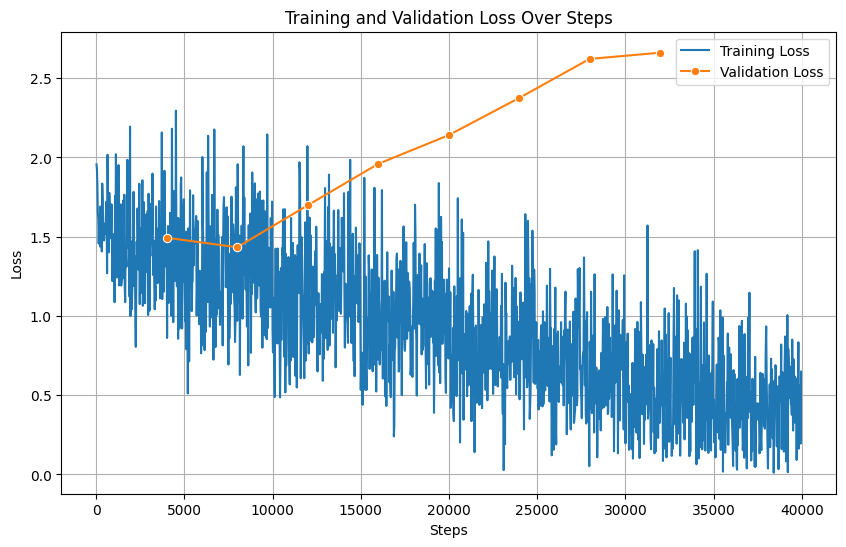

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting training and evaluation loss from trainer.state.log_history
epochs = [entry['epoch'] for entry in trainer.state.log_history if 'eval_loss' in entry]
train_losses = [entry['loss'] for entry in trainer.state.log_history if 'loss' in entry and 'eval_loss' not in entry] # Exclude eval_loss from training loss
val_losses = [entry['eval_loss'] for entry in trainer.state.log_history if 'eval_loss' in entry]
steps_train = [entry['step'] for entry in trainer.state.log_history if 'loss' in entry and 'eval_loss' not in entry]

if trainer.state.global_step and trainer.state.num_train_epochs > 0:
    steps_per_epoch = trainer.state.global_step / trainer.state.num_train_epochs
else:
    print("Warning: Could not determine steps_per_epoch from trainer.state, estimating from last training step.")
    if steps_train and epochs:
        steps_per_epoch = steps_train[-1] / epochs[-1]
    else:
        steps_per_epoch = 1 # Default to 1 if no data available, but plot will be inaccurate

val_steps = [epoch * steps_per_epoch for epoch in epochs]

# Plotting Training and Validation Loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=steps_train, y=train_losses, label='Training Loss')
sns.lineplot(x=val_steps, y=val_losses, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss Over Steps')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

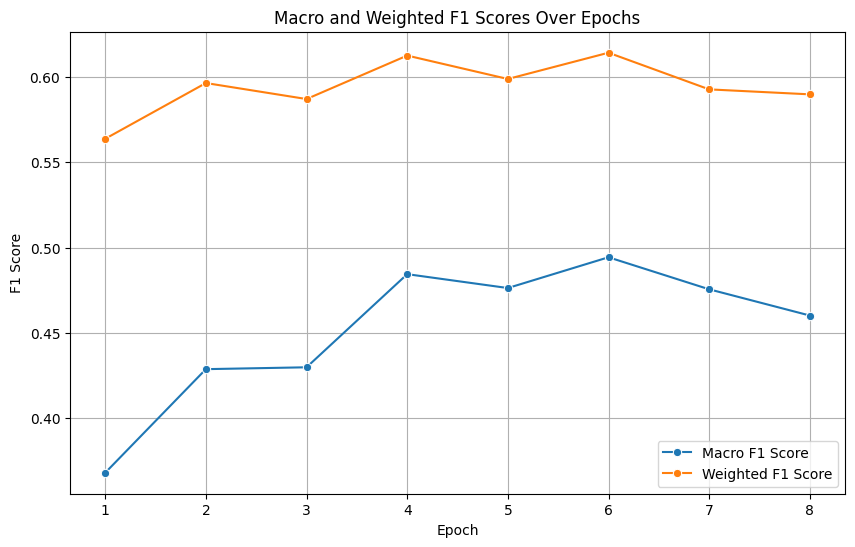

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extracting F1 scores from trainer.state.log_history
epochs_f1 = [entry['epoch'] for entry in trainer.state.log_history if 'eval_macro_f1' in entry]
macro_f1_scores = [entry['eval_macro_f1'] for entry in trainer.state.log_history if 'eval_macro_f1' in entry]
weighted_f1_scores = [entry['eval_weighted_f1'] for entry in trainer.state.log_history if 'eval_weighted_f1' in entry]

# Plotting Macro and Weighted F1 Scores
plt.figure(figsize=(10, 6))
sns.lineplot(x=epochs_f1, y=macro_f1_scores, label='Macro F1 Score', marker='o')
sns.lineplot(x=epochs_f1, y=weighted_f1_scores, label='Weighted F1 Score', marker='o')
plt.title('Macro and Weighted F1 Scores Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.grid(True)
plt.legend()
plt.show()